In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

import scanpy as sc
import numpy as np
import anndata as ad

from tqdm.notebook import tqdm

In [2]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 63378 × 27518
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
tmp = sc.pp.filter_genes(adata, min_cells=1000, inplace=False)[0]
adata[:, tmp]

View of AnnData object with n_obs × n_vars = 63378 × 12797
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [5]:
adata.X.toarray()

array([[0.       , 0.       , 2.0767338, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.0676317, 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

In [6]:
sc.pp.filter_genes(adata, min_cells=1000)

In [28]:
class Autoencoder(nn.Module):
    def __init__(self, dim_in, hidden_dim, dim_out):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(dim_in, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim_out)
        )

        self.decoder = nn.Sequential(
            nn.Linear(dim_out, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim_in)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [29]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = CustomDataset(adata.X.toarray())
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder(
    dim_in=12797,
    hidden_dim=1024,
    dim_out=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [1/100], Loss: 0.2653
Epoch [2/100], Loss: 0.2641
Epoch [3/100], Loss: 0.2645
Epoch [4/100], Loss: 0.2612
Epoch [5/100], Loss: 0.2629
Epoch [6/100], Loss: 0.2619
Epoch [7/100], Loss: 0.2589
Epoch [8/100], Loss: 0.2598
Epoch [9/100], Loss: 0.2577
Epoch [10/100], Loss: 0.2588
Epoch [11/100], Loss: 0.2612
Epoch [12/100], Loss: 0.2606
Epoch [13/100], Loss: 0.2574
Epoch [14/100], Loss: 0.2592
Epoch [15/100], Loss: 0.2589
Epoch [16/100], Loss: 0.2605
Epoch [17/100], Loss: 0.2608
Epoch [18/100], Loss: 0.2601
Epoch [19/100], Loss: 0.2580
Epoch [20/100], Loss: 0.2587
Epoch [21/100], Loss: 0.2563
Epoch [22/100], Loss: 0.2594
Epoch [23/100], Loss: 0.2587
Epoch [24/100], Loss: 0.2577
Epoch [25/100], Loss: 0.2592
Epoch [26/100], Loss: 0.2606
Epoch [27/100], Loss: 0.2595
Epoch [28/100], Loss: 0.2587
Epoch [29/100], Loss: 0.2596
Epoch [30/100], Loss: 0.2611
Epoch [31/100], Loss: 0.2603
Epoch [32/100], Loss: 0.2580
Epoch [33/100], Loss: 0.2611
Epoch [34/100], Loss: 0.2600
Epoch [35/100], Loss: 0

In [32]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model(torch.tensor(orig).float().to(device)).cpu().numpy()

In [33]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


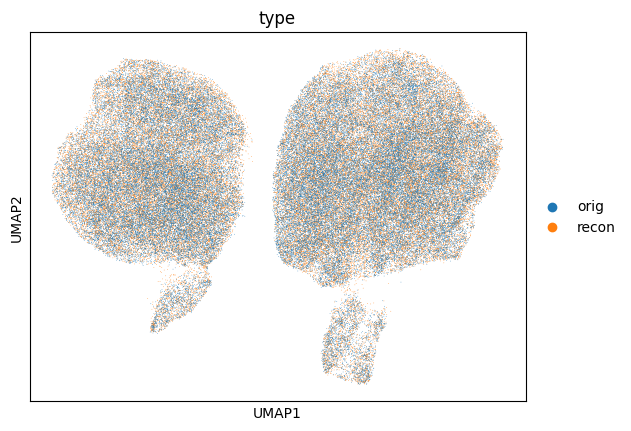

In [34]:
sc.pl.umap(combined, color="type")

In [64]:
model.eval()
with torch.no_grad():
    adata.obsm["latent_10"] = model.encoder(torch.tensor(orig).float().to(device)).cpu().numpy()
adata.write_h5ad("./data/combosciplex_with_ae_latent.h5ad")

In [50]:
torch.save(model.state_dict(), "ae_models/ae_10_dim.ckpt")

In [52]:
Autoencoder(
    dim_in=12797,
    hidden_dim=1024,
    dim_out=10
).load_state_dict(state_dict=torch.load("ae_models/ae_10_dim.ckpt", weights_only=True))

<All keys matched successfully>